# Inferência + Avaliação Out-of-Sample — Pacientes 28 e 72

Pipeline completo de inferência sem dependência de `.atr` para detecção.
O `.atr` é carregado **apenas ao final, para avaliação com ground truth**.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import wfdb.processing as wp
import tensorflow as tf
import joblib
from pathlib import Path
from scipy.signal import butter, filtfilt, savgol_filter
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, sig)

def detect_wave_bounds(sig, peak, fs, search_pre=0.25, search_post=0.40, smooth_window=11):
    pre   = int(search_pre  * fs)
    post  = int(search_post * fs)
    left  = max(0, peak - pre)
    right = min(len(sig) - 1, peak + post)
    seg   = sig[left:right]
    if len(seg) < smooth_window + 2:
        return left, right
    dseg = savgol_filter(seg, smooth_window, 2, deriv=1)
    peak_local   = peak - left
    left_deriv   = np.abs(dseg[:peak_local])
    onset_local  = np.argmin(left_deriv) if len(left_deriv) > 0 else 0
    right_deriv  = np.abs(dseg[peak_local:])
    offset_local = peak_local + (np.argmin(right_deriv) if len(right_deriv) > 0 else 0)
    return left + onset_local, left + offset_local

## 1 — Configurações

In [2]:
DATA_DIR     = Path('data')
MODELS_DIR   = Path('models')
TARGET_LEN   = 200
WINDOW_SEC   = 10
OOS_PATIENTS = ['28', '72']

## 2 — Carregar modelos e artefatos de treino

In [3]:
model2 = tf.keras.models.load_model(MODELS_DIR / 'clean_model2_morphology_final.keras')
model3 = tf.keras.models.load_model(MODELS_DIR / 'clean_model3_rhythm_final.keras')
le2    = joblib.load(MODELS_DIR / 'le2.pkl')

rr_params = json.load(open(MODELS_DIR / 'rr_params.json'))
RR_MEAN = rr_params['rr_mean']
RR_STD  = rr_params['rr_std']

print(f'model2 input : {model2.input_shape}')
print(f'model3 input : {model3.input_shape}')
print(f'Classes CNN  : {le2.classes_}')
print(f'RR_MEAN: {RR_MEAN:.4f}s | RR_STD: {RR_STD:.4f}s ({60/RR_MEAN:.1f} bpm)')

model2 input : (None, 200, 1)
model3 input : (None, 31, 2)
Classes CNN  : ['A' 'N' 'V']
RR_MEAN: 0.0541s | RR_STD: 138.8682s (1109.3 bpm)


## 3 — Detecção de picos QRS (XQRS — apenas .dat)

In [4]:
all_signals, all_fs, all_peaks = {}, {}, {}

for pid in OOS_PATIENTS:
    rec    = wfdb.rdrecord(str(DATA_DIR / pid))
    signal = rec.p_signal[:, 0]
    fs     = rec.fs

    xqrs = wp.XQRS(sig=signal, fs=fs)
    xqrs.detect()
    peaks = xqrs.qrs_inds

    all_signals[pid] = signal
    all_fs[pid]      = fs
    all_peaks[pid]   = peaks

    print(f'[{pid}] {len(peaks)} picos QRS | fs={fs}Hz | dur={len(signal)/fs/3600:.1f}h')

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[28] 99347 picos QRS | fs=128Hz | dur=21.1h
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[72] 144274 picos QRS | fs=128Hz | dur=24.3h


## 4 — Segmentação dos batimentos

In [5]:
all_segs, all_meta = [], []

for pid in OOS_PATIENTS:
    signal = all_signals[pid]
    fs     = all_fs[pid]
    peaks  = all_peaks[pid]

    for peak in peaks:
        onset, offset = detect_wave_bounds(signal, peak, fs)
        seg = signal[onset:offset]
        if len(seg) < 10:
            continue
        x_orig = np.linspace(0, 1, len(seg))
        x_new  = np.linspace(0, 1, TARGET_LEN)
        all_segs.append(interp1d(x_orig, seg, kind='cubic')(x_new))
        all_meta.append({'peak': peak, 'patient': pid})

    print(f'[{pid}] {sum(1 for m in all_meta if m["patient"] == pid)} segmentos válidos')

segments = np.array(all_segs)
df_meta  = pd.DataFrame(all_meta)
print(f'Shape total: {segments.shape}')

[28] 99259 segmentos válidos
[72] 144040 segmentos válidos
Shape total: (243299, 200)


## 5 — Classificação por batimento (Estágio 2 — CNN)

In [6]:
fs = list(all_fs.values())[0]

X_inf = np.array([bandpass(x, fs) for x in segments])
X_inf = (X_inf - X_inf.mean(axis=1, keepdims=True)) / (X_inf.std(axis=1, keepdims=True) + 1e-8)
X_inf = X_inf.reshape(-1, TARGET_LEN, 1)

pred_proba2  = model2.predict(X_inf, batch_size=512)
pred_enc     = np.argmax(pred_proba2, axis=1)
pred_labels  = le2.inverse_transform(pred_enc)

df_meta['pred_symbol'] = pred_labels
df_meta['pred_enc']    = pred_enc

for pid in OOS_PATIENTS:
    sub = df_meta[df_meta['patient'] == pid]
    print(f'[{pid}] Morfologia predita:')
    print(sub['pred_symbol'].value_counts().to_string())
    print()

476/476 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step
[28] Morfologia predita:
pred_symbol
N    97720
V     1162
A      377

[72] Morfologia predita:
pred_symbol
N    142811
V      1095
A       134



## 6 — Classificação por janela de 10s (Estágio 3 — BiLSTM)

In [7]:
results   = {}
win_meta  = {}

for pid in OOS_PATIENTS:
    sub = df_meta[df_meta['patient'] == pid].copy().reset_index(drop=True)
    fs  = all_fs[pid]

    sub['rr']        = sub['peak'].diff().fillna(0) / fs
    sub['window_id'] = (sub['peak'] // (WINDOW_SEC * fs)).astype(int)

    X_seq, win_ids, win_morph = [], [], []
    for wid, group in sub.groupby('window_id'):
        if len(group) < 3:
            continue
        symbol_enc = group['pred_symbol'].map({'N': 0, 'A': 1, 'V': 2}).values
        rr         = group['rr'].values
        X_seq.append(np.stack([symbol_enc, rr], axis=1))
        win_ids.append(wid)
        win_morph.append(group['pred_symbol'].mode()[0])

    MAX_BEATS = max(len(s) for s in X_seq)
    X_pad = pad_sequences(X_seq, maxlen=MAX_BEATS, dtype='float32', padding='post', value=0.0)
    X_pad[:, :, 1] = (X_pad[:, :, 1] - RR_MEAN) / (RR_STD + 1e-8)

    proba = model3.predict(X_pad, batch_size=64).flatten()
    preds = (proba >= 0.5).astype(int)

    df_win = pd.DataFrame({
        'window_id':    win_ids,
        'pred_class':   preds,
        'proba_anorm':  proba,
        'pred_label':   ['Anormal' if p else 'Normal' for p in preds],
        'dominant_morph': win_morph,
    })
    results[pid]  = df_win
    win_meta[pid] = {'MAX_BEATS': MAX_BEATS}

    n_abn = (preds == 1).sum()
    print(f'[{pid}] {len(preds)} janelas | Normal: {(preds==0).sum()} | Anormal: {n_abn} ({100*n_abn/len(preds):.1f}%)')

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
[28] 7578 janelas | Normal: 5593 | Anormal: 1985 (26.2%)
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[72] 8742 janelas | Normal: 1303 | Anormal: 7439 (85.1%)


## 7 — Ground truth via .atr (apenas para avaliação)

In [8]:
# O .atr é lido SOMENTE aqui para gerar ground truth de avaliação.
# Não afeta nenhuma etapa do pipeline de detecção ou classificação.

gt_beat  = {}   # ground truth por batimento
gt_rhythm = {}  # ground truth de ritmo por sample

for pid in OOS_PATIENTS:
    ann    = wfdb.rdann(str(DATA_DIR / pid), 'atr')
    signal = all_signals[pid]
    fs     = all_fs[pid]

    # Ground truth de morfologia por batimento
    ann_mask    = np.isin(ann.symbol, ['N', 'A', 'V'])
    ann_samples = ann.sample[ann_mask]
    ann_symbols = np.array(ann.symbol)[ann_mask]
    gt_beat[pid] = (ann_samples, ann_symbols)

    # Ground truth de ritmo por janela (propaga por tempo)
    ann_rhythm = pd.DataFrame({'sample': ann.sample, 'aux_note': ann.aux_note})
    ann_rhythm = ann_rhythm[ann_rhythm['aux_note'].str.strip().str.startswith('(')]
    ann_rhythm = ann_rhythm.sort_values('sample').drop_duplicates(subset='sample').reset_index(drop=True)

    bins   = [-1] + list(ann_rhythm['sample']) + [len(signal)]
    labels = [''] + list(ann_rhythm['aux_note'])

    df_win = results[pid].copy()
    win_center = (df_win['window_id'] * WINDOW_SEC * fs + WINDOW_SEC * fs / 2).astype(int)
    df_win['true_rhythm'] = pd.cut(win_center, bins=bins, labels=labels, ordered=False).astype(str)

    # Ground truth de janela: Normal se ritmo (N, Anormal caso contrário
    df_win['true_class'] = (df_win['true_rhythm'] != '(N').astype(int)
    results[pid] = df_win

    print(f'[{pid}] Ritmos no .atr: {ann_rhythm["aux_note"].value_counts().to_dict()}')

[28] Ritmos no .atr: {'(N': 271, '(SBR': 161, '(AFIB': 106, '(SVTA': 29, '(AB': 15, '(B': 11, '(T': 1}
[72] Ritmos no .atr: {'(N': 72, '(B': 41, '(AFIB': 29, '(SVTA': 5, '(T': 5, '(SBR': 4, '(AB': 2, '(VT': 1}


## 8 — Avaliação: Morfologia por batimento (Estágio 2)


=== Paciente 28 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.99      1.00      0.99     96424
           A       0.03      0.02      0.02       428
           V       0.87      0.87      0.87      1026

    accuracy                           0.99     97878
   macro avg       0.63      0.63      0.63     97878
weighted avg       0.99      0.99      0.99     97878



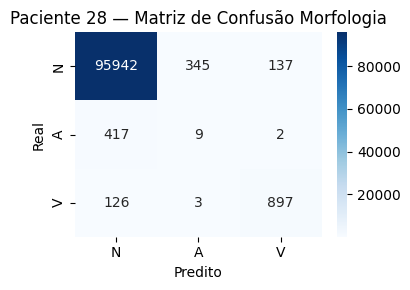


=== Paciente 72 — Morfologia (Estágio 2) ===
              precision    recall  f1-score   support

           N       0.99      1.00      0.99    141619
           A       0.05      0.02      0.03       386
           V       0.78      0.46      0.58      1855

    accuracy                           0.99    143860
   macro avg       0.61      0.49      0.53    143860
weighted avg       0.99      0.99      0.99    143860



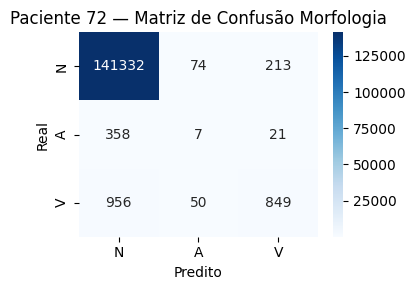

In [9]:
tol = int(0.05 * list(all_fs.values())[0])  # 50ms

for pid in OOS_PATIENTS:
    ann_samples, ann_symbols = gt_beat[pid]
    sub = df_meta[df_meta['patient'] == pid].copy()

    # Para cada batimento predito, busca ground truth mais próximo
    y_true_beat, y_pred_beat = [], []
    for _, row in sub.iterrows():
        diffs = np.abs(ann_samples - row['peak'])
        idx   = np.argmin(diffs)
        if diffs[idx] <= tol:
            y_true_beat.append(ann_symbols[idx])
            y_pred_beat.append(row['pred_symbol'])

    y_true_beat = np.array(y_true_beat)
    y_pred_beat = np.array(y_pred_beat)
    classes     = ['N', 'A', 'V']

    print(f'\n=== Paciente {pid} — Morfologia (Estágio 2) ===')
    print(classification_report(y_true_beat, y_pred_beat, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_beat, y_pred_beat, labels=classes)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes,
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Paciente {pid} — Matriz de Confusão Morfologia')
    plt.tight_layout(); plt.show()

## 9 — Avaliação: Ritmo por janela (Estágio 3)


=== Paciente 28 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      5656
     Anormal       0.94      0.97      0.96      1922

    accuracy                           0.98      7578
   macro avg       0.97      0.97      0.97      7578
weighted avg       0.98      0.98      0.98      7578



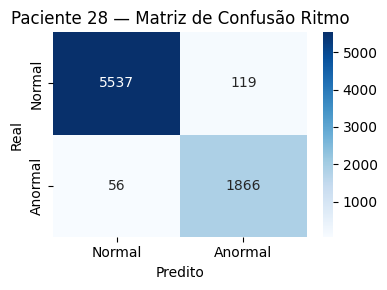

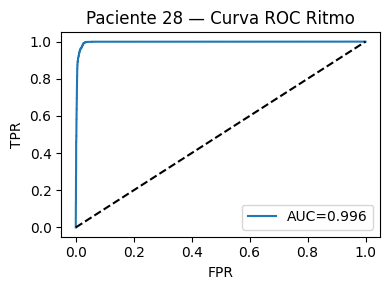

AUC: 0.9964

=== Paciente 72 — Ritmo (Estágio 3) ===
              precision    recall  f1-score   support

      Normal       0.99      0.91      0.95      1418
     Anormal       0.98      1.00      0.99      7324

    accuracy                           0.98      8742
   macro avg       0.99      0.95      0.97      8742
weighted avg       0.98      0.98      0.98      8742



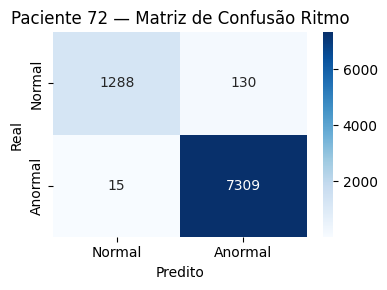

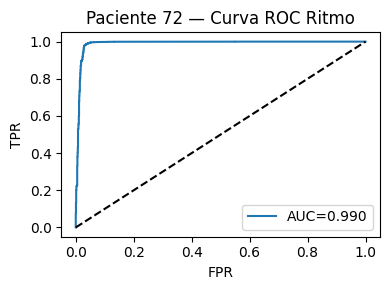

AUC: 0.9899


In [10]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    y_true = df_win['true_class'].astype(int).values
    y_pred = df_win['pred_class'].values
    y_prob = df_win['proba_anorm'].values

    print(f'\n=== Paciente {pid} — Ritmo (Estágio 3) ===')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anormal'], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['Normal', 'Anormal'],
                yticklabels=['Normal', 'Anormal'],
                cmap='Blues', ax=ax)
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(f'Paciente {pid} — Matriz de Confusão Ritmo')
    plt.tight_layout(); plt.show()

    # Curva ROC
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.figure(figsize=(4, 3))
        plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.title(f'Paciente {pid} — Curva ROC Ritmo')
        plt.legend(); plt.tight_layout(); plt.show()
        print(f'AUC: {auc:.4f}')

## 10 — Acurácia por Morfologia × Ritmo (heatmap)

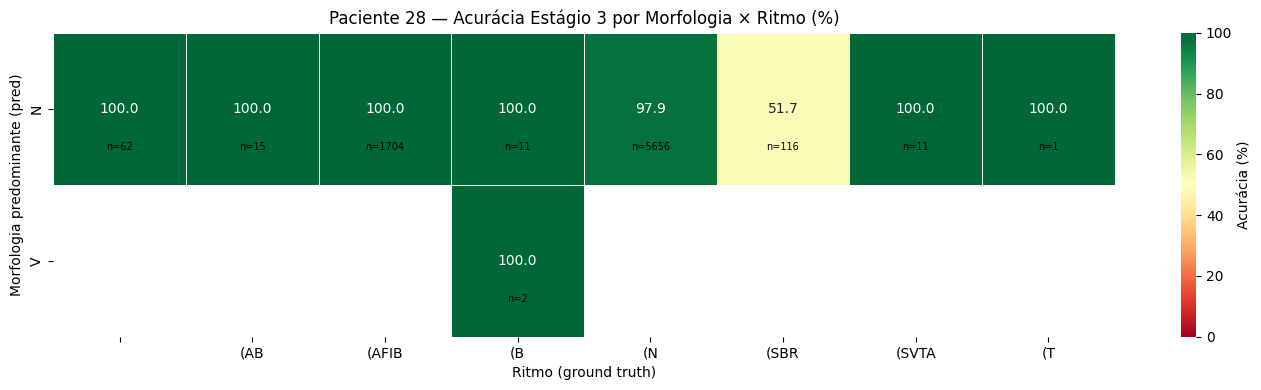

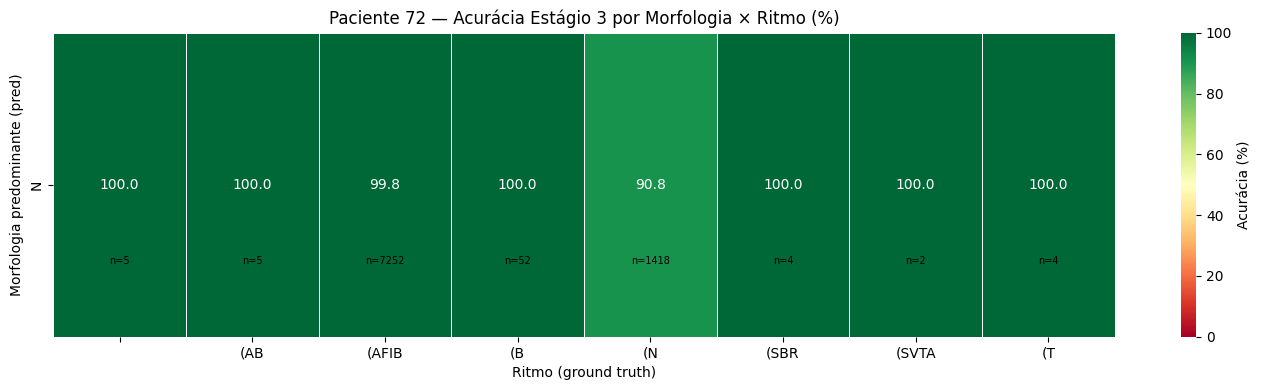

In [11]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    df_win['correct'] = (df_win['true_class'].astype(int) == df_win['pred_class']).astype(int)

    pivot = df_win.groupby(['dominant_morph', 'true_rhythm'])['correct'].agg(['mean','count']).reset_index()
    pivot['mean'] = (pivot['mean'] * 100).round(1)

    acc_mat   = pivot.pivot(index='dominant_morph', columns='true_rhythm', values='mean')
    count_mat = pivot.pivot(index='dominant_morph', columns='true_rhythm', values='count')

    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(acc_mat, annot=True, fmt='.1f', cmap='RdYlGn',
                vmin=0, vmax=100, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Acurácia (%)'})
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            val = count_mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(j + 0.5, i + 0.75, f'n={int(val)}',
                        ha='center', va='center', fontsize=7, color='black')
    ax.set_title(f'Paciente {pid} — Acurácia Estágio 3 por Morfologia × Ritmo (%)')
    ax.set_xlabel('Ritmo (ground truth)'); ax.set_ylabel('Morfologia predominante (pred)')
    plt.tight_layout(); plt.show()

## 11 — Timeline de probabilidade por janela

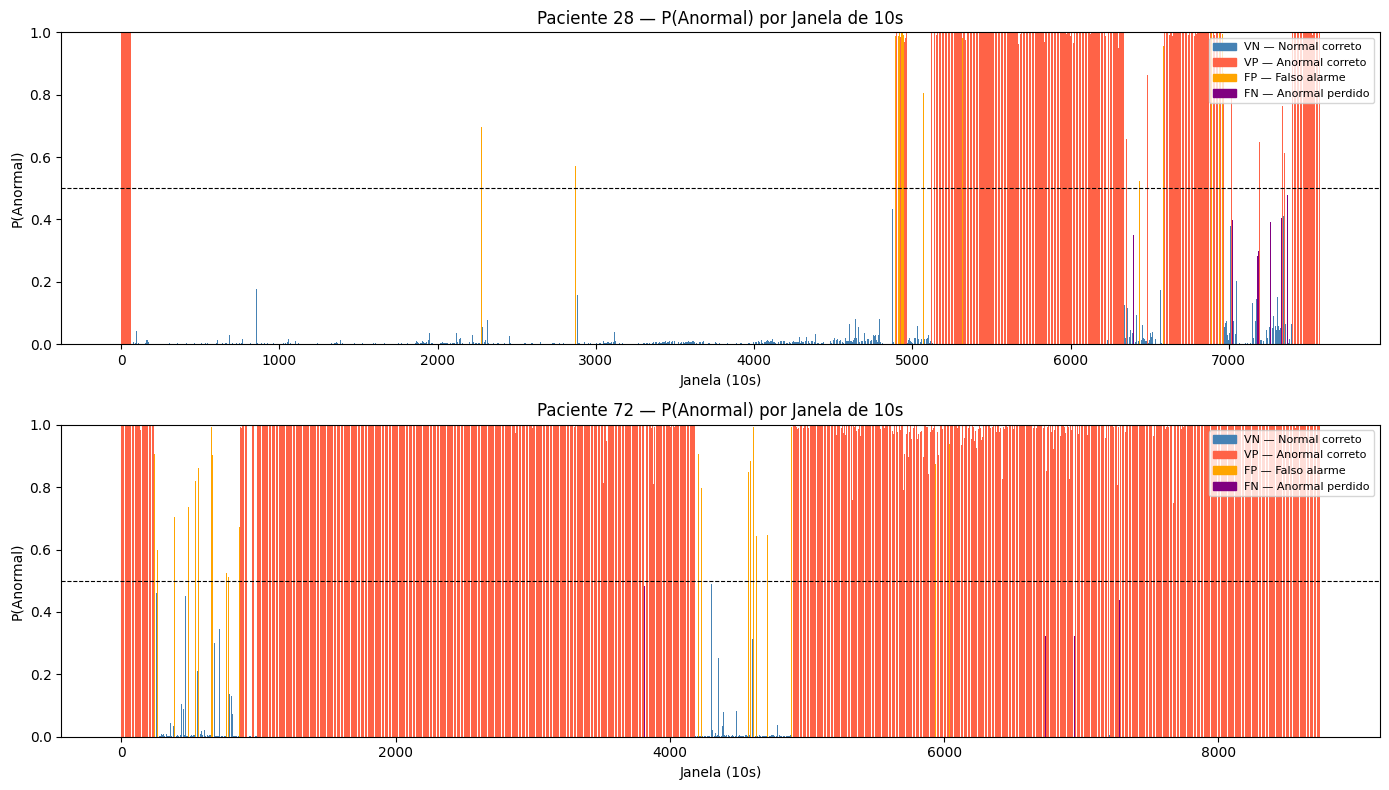

In [12]:
fig, axes = plt.subplots(len(OOS_PATIENTS), 1, figsize=(14, 4 * len(OOS_PATIENTS)))
if len(OOS_PATIENTS) == 1: axes = [axes]

for ax, pid in zip(axes, OOS_PATIENTS):
    df_win = results[pid].dropna(subset=['true_class']).copy()
    colors = []
    for _, row in df_win.iterrows():
        if row['pred_class'] == 1 and row['true_class'] == 1:
            colors.append('tomato')        # VP — anormal correto
        elif row['pred_class'] == 0 and row['true_class'] == 0:
            colors.append('steelblue')     # VN — normal correto
        elif row['pred_class'] == 1 and row['true_class'] == 0:
            colors.append('orange')        # FP — falso alarme
        else:
            colors.append('purple')        # FN — anormal perdido

    ax.bar(df_win['window_id'], df_win['proba_anorm'], color=colors, width=0.8)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Paciente {pid} — P(Anormal) por Janela de 10s')
    ax.set_xlabel('Janela (10s)'); ax.set_ylabel('P(Anormal)')
    ax.legend(handles=[
        plt.Rectangle((0,0),1,1, color='steelblue', label='VN — Normal correto'),
        plt.Rectangle((0,0),1,1, color='tomato',    label='VP — Anormal correto'),
        plt.Rectangle((0,0),1,1, color='orange',    label='FP — Falso alarme'),
        plt.Rectangle((0,0),1,1, color='purple',    label='FN — Anormal perdido'),
    ], loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

## 12 — Resumo consolidado

In [13]:
for pid in OOS_PATIENTS:
    df_win = results[pid].dropna(subset=['true_class']).copy()
    sub    = df_meta[df_meta['patient'] == pid]
    y_true = df_win['true_class'].astype(int).values
    y_pred = df_win['pred_class'].values

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)

    sens = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    spec = tn / (tn + fp) if (tn + fp) > 0 else float('nan')
    auc  = roc_auc_score(y_true, df_win['proba_anorm'].values) if len(np.unique(y_true)) > 1 else float('nan')

    print(f'Paciente {pid}')
    print(f'  Batimentos segmentados : {len(sub)}')
    print(f'  Morfologia predita     : {sub["pred_symbol"].value_counts().to_dict()}')
    print(f'  Janelas avaliadas      : {len(df_win)}')
    print(f'  Sensitivity            : {sens:.3f}')
    print(f'  Specificity            : {spec:.3f}')
    print(f'  AUC                    : {auc:.3f}')
    print()

Paciente 28
  Batimentos segmentados : 99259
  Morfologia predita     : {'N': 97720, 'V': 1162, 'A': 377}
  Janelas avaliadas      : 7578
  Sensitivity            : 0.971
  Specificity            : 0.979
  AUC                    : 0.996

Paciente 72
  Batimentos segmentados : 144040
  Morfologia predita     : {'N': 142811, 'V': 1095, 'A': 134}
  Janelas avaliadas      : 8742
  Sensitivity            : 0.998
  Specificity            : 0.908
  AUC                    : 0.990

